In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [15]:
df=pd.read_csv('/content/car_prices.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [16]:
df = df.rename(columns={'odometer': 'mileage','mmr':'pred_price'})

In [17]:
df['saledate']=pd.to_datetime(df['saledate'], errors='coerce',)

/tmp/ipython-input-830/1494733144.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate']=pd.to_datetime(df['saledate'], errors='coerce',)
/tmp/ipython-input-830/1494733144.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['saledate']=pd.to_datetime(df['saledate'], errors='coerce',)


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   mileage       558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  pred_price    558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558799 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


In [19]:
df['saledate']=pd.to_datetime(df['saledate'], errors='coerce',)
df['month']=df['saledate'].dt.month
df['month']=df['month'].fillna(0.0)

In [20]:
df['saleyear']=df['saledate'].dt.year
df['saleyear']=df['saleyear'].fillna(0.0)

In [21]:
df2=df.copy()
df2.saledate=df.saledate.fillna('unsold')

In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   mileage       558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  pred_price    558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558837 non-null  object 
 16  month         558837 non-null  float64
 17  saleyear      558837 non-null  float64
dtypes: f

In [23]:
df2[['make','saledate','month','saleyear']]

,make,saledate,month,saleyear
0,Kia,2014-12-16 12:30:00+08:00,12.0,2014.0
1,Kia,2014-12-16 12:30:00+08:00,12.0,2014.0
2,BMW,2015-01-15 04:30:00+08:00,1.0,2015.0
3,Volvo,2015-01-29 04:30:00+08:00,1.0,2015.0
4,BMW,2014-12-18 12:30:00+08:00,12.0,2014.0
...,...,...,...,...
558832,Kia,unsold,0.0,0.0
558833,Ram,unsold,0.0,0.0
558834,BMW,unsold,0.0,0.0
558835,Nissan,unsold,0.0,0.0


In [24]:
df2.dropna(subset=['transmission'],inplace=True)

In [25]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493485 entries, 0 to 558836
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          493485 non-null  int64  
 1   make          484945 non-null  object 
 2   model         484853 non-null  object 
 3   trim          484629 non-null  object 
 4   body          482453 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           493481 non-null  object 
 7   state         493485 non-null  object 
 8   condition     483550 non-null  float64
 9   mileage       493422 non-null  float64
 10  color         492890 non-null  object 
 11  interior      492890 non-null  object 
 12  seller        493485 non-null  object 
 13  pred_price    493448 non-null  float64
 14  sellingprice  493474 non-null  float64
 15  saledate      493485 non-null  object 
 16  month         493485 non-null  float64
 17  saleyear      493485 non-null  float64
dtypes: float6

In [26]:
df2.dropna(subset='body',inplace=True)

In [27]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 482453 entries, 0 to 558836
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          482453 non-null  int64  
 1   make          482453 non-null  object 
 2   model         482361 non-null  object 
 3   trim          482453 non-null  object 
 4   body          482453 non-null  object 
 5   transmission  482453 non-null  object 
 6   vin           482449 non-null  object 
 7   state         482453 non-null  object 
 8   condition     472994 non-null  float64
 9   mileage       482398 non-null  float64
 10  color         481872 non-null  object 
 11  interior      481872 non-null  object 
 12  seller        482453 non-null  object 
 13  pred_price    482416 non-null  float64
 14  sellingprice  482442 non-null  float64
 15  saledate      482453 non-null  object 
 16  month         482453 non-null  float64
 17  saleyear      482453 non-null  float64
dtypes: float6

In [28]:
top10=df2.nlargest(10,'sellingprice')
top10[['make','sellingprice']]

,make,sellingprice
344905,Ford,230000.0
548169,Ferrari,183000.0
446949,Mercedes-Benz,173000.0
545523,Rolls-Royce,171500.0
125095,Rolls-Royce,169500.0
557570,Rolls-Royce,169000.0
538347,Rolls-Royce,167000.0
146917,BMW,165000.0
283534,BMW,165000.0
194349,Rolls-Royce,163000.0


In [29]:
b = df2['body'].str.lower()

df2['body_category'] = np.select(
    [
        b.str.contains('cab|supercrew|supercab|crewmax|xtracab', na=False),
        b.str.contains('sedan', na=False),
        b.str.contains('coupe|koup', na=False),
        b.str.contains('convertible', na=False),
        b.str.contains('wagon', na=False),
        b.str.contains('hatchback', na=False),
        b.str.contains('van', na=False),
        b.str.contains('suv', na=False),
    ],
    [
        'Cab',
        'Sedan',
        'Coupe',
        'Convertible',
        'Wagon',
        'Hatchback',
        'Van',
        'SUV'
    ],
    default='Other'
)

In [30]:
df2.body_category.value_counts()

,count
body_category,
Sedan,222327
SUV,123760
Cab,41656
Van,27200
Hatchback,24242
Coupe,18594
Wagon,14656
Convertible,9992
Other,26


In [31]:
soldbodytypes=df2.loc[df2['month'] != 0 ,['body_category']].value_counts()
soldbodytypes

,count
body_category,
Sedan,158212
SUV,87983
Cab,29634
Van,19907
Hatchback,16718
Coupe,13192
Wagon,10775
Convertible,6987


Text(0.5, 1.0, 'Sold Body Types')

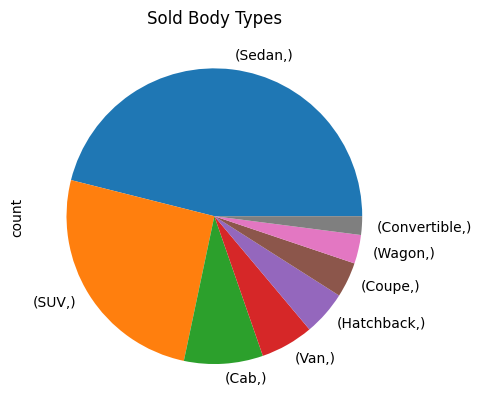

In [77]:
soldbodytypes.plot(kind='pie')
plt.title('Sold Body Types')

In [33]:
costliest_bodytype = df2.groupby('body_category')['sellingprice'].max().sort_values(ascending=False)
display(costliest_bodytype)

,sellingprice
body_category,
SUV,230000.0
Coupe,183000.0
Sedan,173000.0
Convertible,163000.0
Van,84000.0
Hatchback,67500.0
Cab,65000.0
Wagon,50500.0
Other,14300.0


In [34]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 482453 entries, 0 to 558836
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   year           482453 non-null  int64  
 1   make           482453 non-null  object 
 2   model          482361 non-null  object 
 3   trim           482453 non-null  object 
 4   body           482453 non-null  object 
 5   transmission   482453 non-null  object 
 6   vin            482449 non-null  object 
 7   state          482453 non-null  object 
 8   condition      472994 non-null  float64
 9   mileage        482398 non-null  float64
 10  color          481872 non-null  object 
 11  interior       481872 non-null  object 
 12  seller         482453 non-null  object 
 13  pred_price     482416 non-null  float64
 14  sellingprice   482442 non-null  float64
 15  saledate       482453 non-null  object 
 16  month          482453 non-null  float64
 17  saleyear       482453 non-null  fl

In [35]:
df.seller.unique()

array(['kia motors america  inc',
       'financial services remarketing (lease)',
       'volvo na rep/world omni', ..., 'maserati north america inc',
       'alternative financial group inc', 'i -5 uhlmann rv'], dtype=object)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype                                 
---  ------        --------------   -----                                 
 0   year          558837 non-null  int64                                 
 1   make          548536 non-null  object                                
 2   model         548438 non-null  object                                
 3   trim          548186 non-null  object                                
 4   body          545642 non-null  object                                
 5   transmission  493485 non-null  object                                
 6   vin           558833 non-null  object                                
 7   state         558837 non-null  object                                
 8   condition     547017 non-null  float64                               
 9   mileage       558743 non-null  float64                     

In [37]:
df.dropna(subset=['saledate'], inplace = True)
df.dropna(subset=['condition'],inplace=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 383696 entries, 0 to 403182
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype                                 
---  ------        --------------   -----                                 
 0   year          383696 non-null  int64                                 
 1   make          376775 non-null  object                                
 2   model         376711 non-null  object                                
 3   trim          376518 non-null  object                                
 4   body          374411 non-null  object                                
 5   transmission  341890 non-null  object                                
 6   vin           383696 non-null  object                                
 7   state         383696 non-null  object                                
 8   condition     383696 non-null  float64                               
 9   mileage       383678 non-null  float64                          

In [39]:
df['make'] = df['make'].astype(str).str.lower().str.strip()

mapping = {
    'vw': 'volkswagen',
    'mercedes-b': 'mercedes-benz',
    'mercedes': 'mercedes-benz',
    'landrover': 'land rover',
    'gmc truck': 'gmc',
    'dodge tk': 'dodge',
    'hyundai tk': 'hyundai',
    'mazda tk': 'mazda',
    'ford tk': 'ford',
    'ford truck': 'ford',
    'chev truck': 'chevrolet',
    'chevrolet': 'chevrolet'
}

df['make'] = df['make'].replace(mapping)

# Final formatting to title case
df['make'] = df['make'].str.title()

# Handle 'Nan' strings created by astype(str) if necessary
df.dropna(subset=['make'], inplace=True)

In [40]:
df.drop(df[df['make'] == 'Nan'].index, inplace=True)

In [41]:
df.make.unique()

array(['Kia', 'Bmw', 'Volvo', 'Nissan', 'Chevrolet', 'Audi', 'Ford',
       'Buick', 'Cadillac', 'Acura', 'Lexus', 'Hyundai', 'Infiniti',
       'Jeep', 'Mercedes-Benz', 'Mitsubishi', 'Mazda', 'Mini',
       'Land Rover', 'Lincoln', 'Jaguar', 'Volkswagen', 'Toyota',
       'Subaru', 'Scion', 'Porsche', 'Dodge', 'Fiat', 'Chrysler',
       'Ferrari', 'Honda', 'Gmc', 'Ram', 'Smart', 'Bentley', 'Pontiac',
       'Saturn', 'Maserati', 'Mercury', 'Hummer', 'Saab', 'Suzuki',
       'Oldsmobile', 'Geo', 'Rolls-Royce', 'Isuzu', 'Plymouth', 'Tesla',
       'Airstream', 'Dot', 'Aston Martin', 'Fisker', 'Daewoo',
       'Lamborghini'], dtype=object)

In [42]:
df['make'].value_counts().head(10)

,count
make,
Ford,65452
Chevrolet,42279
Nissan,36056
Toyota,26700
Dodge,21744
Honda,19821
Hyundai,14729
Bmw,13822
Kia,12481


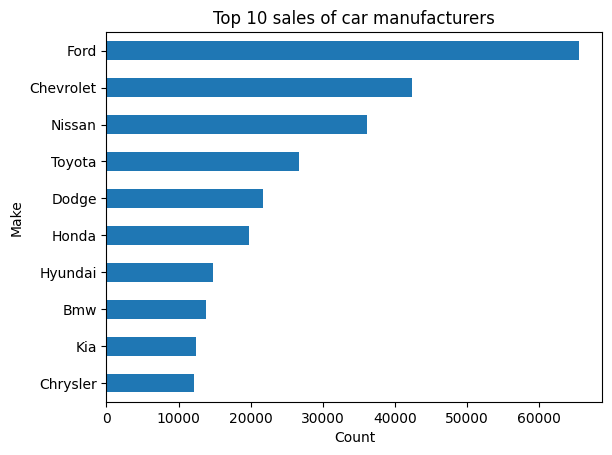

In [79]:
df['make'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 sales of car manufacturers')
plt.xlabel('Count')
plt.ylabel('Make')
plt.gca().invert_yaxis()

In [44]:
df.transmission.value_counts()

,count
transmission,
automatic,324177
manual,11860


Text(0, 0.5, '')

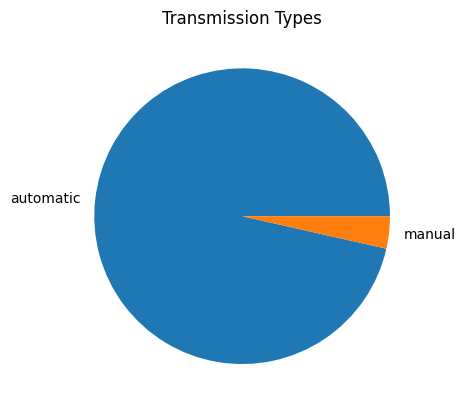

In [45]:
df.transmission.value_counts().plot(kind='pie')
plt.title('Transmission Types')
plt.ylabel('')

In [81]:
df.loc[df['transmission']=='manual',['make','model','trim','transmission']].value_counts().head(10)

,,,,count
make,model,trim,transmission,
Mini,Cooper,S,manual,267
Honda,Civic,Si,manual,247
Mini,Cooper,Base,manual,218
Honda,Civic,LX,manual,138
Ford,Mustang,GT Premium,manual,136
Kia,Soul,Base,manual,135
Ford,Focus,SE,manual,134
Jeep,Wrangler,Sport,manual,133
Honda,Civic,EX,manual,131


In [47]:
df.loc[df['transmission']=='automatic',['make','model','trim','transmission']].value_counts().head(10)

make      model             trim     transmission
Nissan    Altima            2.5 S    automatic       7374
Ford      Fusion            SE       automatic       5482
          Focus             SE       automatic       5264
          F-150             XLT      automatic       3987
Nissan    Altima            2.5      automatic       3648
Toyota    Camry             LE       automatic       3546
Dodge     Grand Caravan     SXT      automatic       2975
Chrysler  Town and Country  Touring  automatic       2756
Honda     Civic             LX       automatic       2711
Hyundai   Sonata            GLS      automatic       2649
Name: count, dtype: int64

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376775 entries, 0 to 403182
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype                                 
---  ------        --------------   -----                                 
 0   year          376775 non-null  int64                                 
 1   make          376775 non-null  object                                
 2   model         376711 non-null  object                                
 3   trim          376518 non-null  object                                
 4   body          374411 non-null  object                                
 5   transmission  336037 non-null  object                                
 6   vin           376775 non-null  object                                
 7   state         376775 non-null  object                                
 8   condition     376775 non-null  float64                               
 9   mileage       376759 non-null  float64                          

In [49]:
top_selling=df.groupby(['state','make','model']).size().reset_index(name='count').sort_values(['count'],ascending=False).groupby('state').head(1)
top_selling

,state,make,model,count
2322,fl,Nissan,Altima,2500
1193,ca,Nissan,Altima,2195
10563,pa,Nissan,Altima,1466
12180,tx,Ford,F-150,1394
8070,nj,Nissan,Altima,1219
3738,il,Nissan,Altima,1154
5530,mi,Ford,F-150,998
11850,tn,Nissan,Altima,898
3084,ga,Toyota,Camry,735
6327,mo,Ford,Escape,662


In [50]:
df.groupby(['state','seller']).size().reset_index(name='count').sort_values(['count'],ascending=False).groupby('state').head(1)

,state,seller,count
11646,pa,r hollenshead auto sales inc,2974
3624,fl,nissan-infiniti lt,2432
5313,il,ford motor credit company llc,2091
9006,nj,nissan-infiniti lt,1953
12955,tx,avis corporation,1914
1543,ca,nissan infiniti lt,1909
6584,mi,ford motor credit company llc,1484
12534,tn,ford motor credit company llc,1361
8347,nc,santander consumer,1085
10397,oh,toyota financial services,947


In [51]:
df.groupby(['state','body']).size().reset_index(name='count').sort_values(['count'],ascending=False).groupby('state').head(1)

,state,body,count
150,fl,Sedan,25799
82,ca,Sedan,23509
688,pa,Sedan,15235
821,tx,Sedan,12396
187,ga,Sedan,10923
519,nj,Sedan,8520
245,il,Sedan,7505
460,nc,Sedan,7135
612,oh,Sedan,6743
785,tn,Sedan,6181


In [88]:
df.loc[(df['state']=='ca')&(df['saleyear']==2015),['state','body']].value_counts()

state  body                   
ca     Sedan                      19409
       SUV                        10069
       Hatchback                   2844
       Coupe                       2024
       Minivan                     1691
       Convertible                 1620
       Wagon                       1439
       Crew Cab                    1182
       G Sedan                     1039
       SuperCrew                    436
       Regular Cab                  358
       Extended Cab                 355
       SuperCab                     291
       G Coupe                      274
       Van                          269
       Quad Cab                     260
       Double Cab                   126
       E-Series Van                  95
       King Cab                      94
       G Convertible                 61
       CrewMax Cab                   54
       sedan                         34
       Access Cab                    30
       Genesis Coupe                 29
       minivan                       20
       Club Cab                      17
       Beetle Convertible            13
       Xtracab                       11
       Koup                          11
       Elantra Coupe                  7
       CTS Coupe                      6
       TSX Sport Wagon                5
       CTS-V Coupe                    3
       GranTurismo Convertible        3
       Q60 Convertible                2
       Promaster Cargo Van            2
       CTS-V Wagon                    1
       G37 Coupe                      1
       Ram Van                        1
       Q60 Coupe                      1
       convertible                    1
Name: count, dtype: int64

In [91]:
sellertopsales=df.groupby(['seller','make','model']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)
top_10=sellertopsales.nlargest(10,'count')
print(top_10)

                                        seller           make     model  count
73644                       nissan-infiniti lt         Nissan    Altima   6895
73351                       nissan infiniti lt       Infiniti   G Sedan   4592
42921            ford motor credit company llc           Ford    Escape   2616
2735      ahfc/honda lease trust/hvt  inc. eot          Honda    Accord   1874
53097                    hyundai motor finance        Hyundai    Sonata   1640
67222         mercedes-benz financial services  Mercedes-Benz   C-Class   1585
39650   financial services remarketing (lease)            Bmw  3 Series   1454
102841      toyota motor sales usa inc/program         Toyota     Camry   1251
110318        world omni financial corporation         Toyota     Camry    916
58274                  kia motors america  inc            Kia    Optima    870


In [54]:
df.seller.value_counts()

,count
seller,
ford motor credit company llc,13588
nissan-infiniti lt,12833
santander consumer,11032
avis corporation,9359
the hertz corporation,9237
...,...
bar none auction,1
affordable t motors,1
mainstreet financial group,1


In [55]:
df.loc[df['saleyear']==2014,['seller']].value_counts()

,count
seller,
santander consumer,1755
wells fargo dealer services,1354
nissan-infiniti lt,1155
ford motor credit company llc,1005
ge fleet services for itself/servicer,921
...,...
weston auto gallery,1
brooklyn pk automotive inc,1
brodhead chevrolet buick llc,1


In [56]:
df.loc[df['saleyear']==2015,['seller']].value_counts()

,count
seller,
ford motor credit company llc,12583
nissan-infiniti lt,11678
santander consumer,9277
avis corporation,8885
the hertz corporation,8657
...,...
platinum automotive group llc,1
carolina finance llc,1
carlson toyota,1


In [57]:
df['quarter'] = pd.cut(df['month'],bins=[0, 3, 6, 9, 12],labels=['Q1', 'Q2', 'Q3', 'Q4'])

In [58]:
df[df['year']==2014].groupby(['seller','month']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)

,seller,month,count
304,avis corporation,2.0,2409
1560,gm remarketing,2.0,1541
1139,enterprise veh exchange/rental,1.0,1365
1934,kia motors america inc,2.0,1288
299,avis budget group,1.0,1226
...,...,...,...
3587,winner subaru/vw of dover,1.0,1
0,1 cochran of monroeville,2.0,1
3616,ws healey chevrolet buick inc,2.0,1
31,ace auto sales,2.0,1


In [59]:
df[df['year']==2015].groupby(['seller','month']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)

,seller,month,count
311,kia motors america inc,2.0,346
159,enterprise veh exchange/rental,2.0,272
163,enterprise vehicle exchange / tra / rental / t...,2.0,133
518,volvo na rep/world omni,2.0,110
29,ars/enterprise,2.0,92
...,...,...,...
537,white county ford llc,2.0,1
536,wheels of fortune auto inc,2.0,1
535,weston auto gallery,2.0,1
534,west palm financial group llc,2.0,1


In [60]:
df[df['year']==2014].groupby(['seller','quarter']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)

/tmp/ipython-input-830/4031095156.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['year']==2014].groupby(['seller','quarter']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)


,seller,quarter,count
712,avis corporation,Q1,4271
3556,gm remarketing,Q1,2750
708,avis budget group,Q1,2681
2668,enterprise veh exchange/rental,Q1,2624
4472,kia motors america inc,Q1,2531
...,...,...,...
8692,york dodge chrysler jeep ram,Q1,1
8688,yates buick gmc inc,Q1,1
12,2020 motors,Q1,1
36,a and d motors llc,Q1,1


In [61]:
df[df['year']==2015].groupby(['seller','quarter']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)

/tmp/ipython-input-830/2330779431.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['year']==2015].groupby(['seller','quarter']).size().reset_index(name='count').sort_values('count',ascending=False).groupby('seller').head(1)


,seller,quarter,count
736,kia motors america inc,Q1,569
412,enterprise veh exchange/rental,Q1,524
416,enterprise vehicle exchange / tra / rental / t...,Q1,287
1288,volvo na rep/world omni,Q1,186
76,ars/enterprise,Q1,144
...,...,...,...
348,don beyer motors inc,Q1,1
352,don davis nissan inc,Q1,1
396,elite motors inc,Q1,1
400,enterprise car sales/orange,Q1,1


In [62]:
df.loc[df['saleyear']==2014,['seller']].value_counts()

,count
seller,
santander consumer,1755
wells fargo dealer services,1354
nissan-infiniti lt,1155
ford motor credit company llc,1005
ge fleet services for itself/servicer,921
...,...
weston auto gallery,1
brooklyn pk automotive inc,1
brodhead chevrolet buick llc,1


In [63]:
df.loc[(df['saleyear']==2014),['quarter','month']].value_counts()

quarter  month
Q4       12.0     41726
Q1       1.0        206
         2.0          1
Name: count, dtype: int64

In [64]:
df.loc[(df['saleyear']==2015),['quarter','month']].value_counts()

quarter  month
Q1       2.0      159114
         1.0      138527
         3.0       37201
Name: count, dtype: int64

In [65]:
df.loc[(df['saleyear']==2014)&(df['seller']=='ford motor credit company llc'),['quarter']].value_counts()


,count
quarter,
Q4,983
Q1,22
Q2,0
Q3,0


Text(0.5, 1.0, 'year 2014 sales per month')

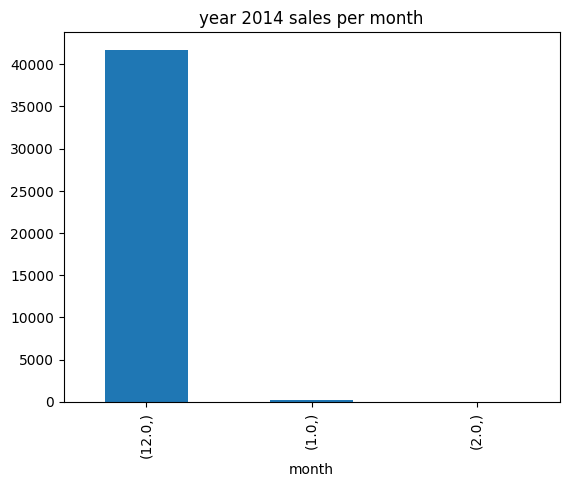

In [66]:
df.loc[df['saleyear']==2014,['month']].value_counts().plot(kind='bar')
plt.title('year 2014 sales per month')

Text(0.5, 1.0, 'year 2015 sales per month')

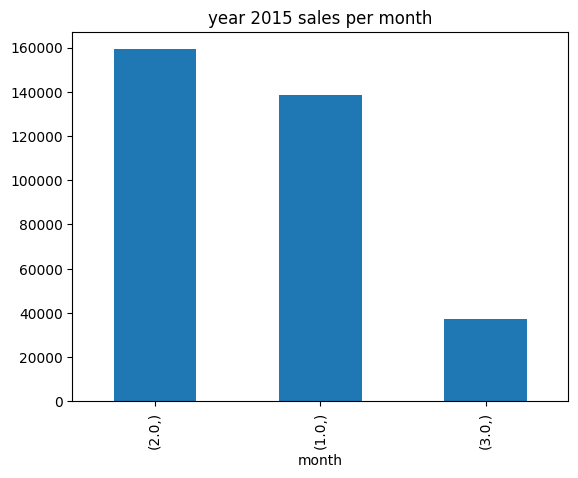

In [67]:
df.loc[df['saleyear']==2015,['month']].value_counts().plot(kind='bar')
plt.title('year 2015 sales per month')

In [68]:
df['condi_rating']=pd.qcut(df['condition'],q=5,labels=[1,2,3,4,5])

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376775 entries, 0 to 403182
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype                                 
---  ------        --------------   -----                                 
 0   year          376775 non-null  int64                                 
 1   make          376775 non-null  object                                
 2   model         376711 non-null  object                                
 3   trim          376518 non-null  object                                
 4   body          374411 non-null  object                                
 5   transmission  336037 non-null  object                                
 6   vin           376775 non-null  object                                
 7   state         376775 non-null  object                                
 8   condition     376775 non-null  float64                               
 9   mileage       376759 non-null  float64                          

In [70]:
df[df['saleyear']==2014].groupby('condi_rating')['sellingprice'].max()

/tmp/ipython-input-830/3515025637.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['saleyear']==2014].groupby('condi_rating')['sellingprice'].max()


,sellingprice
condi_rating,
1,149800.0
2,58000.0
3,113000.0
4,154000.0
5,156000.0


In [71]:
df[df['saleyear']==2015].groupby('condi_rating')['sellingprice'].max()

/tmp/ipython-input-830/724864070.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['saleyear']==2015].groupby('condi_rating')['sellingprice'].max()


,sellingprice
condi_rating,
1,165000.0
2,117000.0
3,108200.0
4,230000.0
5,169500.0


/tmp/ipython-input-830/830917425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['saleyear']==2014].groupby('condi_rating')['sellingprice'].max().plot(kind='bar')


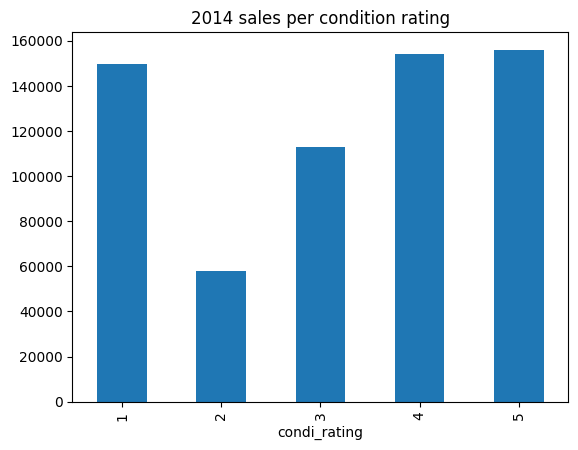

/tmp/ipython-input-830/830917425.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['saleyear']==2015].groupby('condi_rating')['sellingprice'].max().plot(kind='bar')


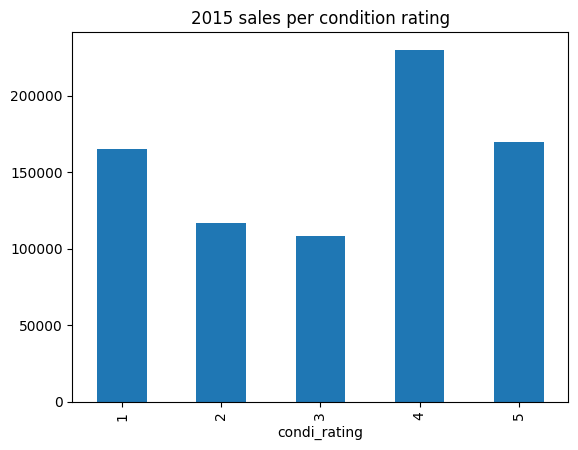

In [72]:
df[df['saleyear']==2014].groupby('condi_rating')['sellingprice'].max().plot(kind='bar')
plt.title('2014 sales per condition rating')
plt.show()
df[df['saleyear']==2015].groupby('condi_rating')['sellingprice'].max().plot(kind='bar')
plt.title('2015 sales per condition rating')
plt.show()

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 376775 entries, 0 to 403182
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype                                 
---  ------        --------------   -----                                 
 0   year          376775 non-null  int64                                 
 1   make          376775 non-null  object                                
 2   model         376711 non-null  object                                
 3   trim          376518 non-null  object                                
 4   body          374411 non-null  object                                
 5   transmission  336037 non-null  object                                
 6   vin           376775 non-null  object                                
 7   state         376775 non-null  object                                
 8   condition     376775 non-null  float64                               
 9   mileage       376759 non-null  float64                          

In [74]:
df['mileage']

,mileage
0,16639.0
1,9393.0
2,1331.0
3,14282.0
4,2641.0
...,...
402848,47032.0
403065,225849.0
403141,161496.0
403180,168356.0
